# 線形最適化問題入門

# 2.1.3 Pythonで解いてみる

## コード2.1（p. 28）

In [1]:
from pulp import *
# 関数の定義
prob = LpProblem(name='LP-Sample', sense=LpMaximize)
x1 = LpVariable('x1', lowBound=0.0)
x2 = LpVariable('x2', lowBound=0.0)



prob += 2*x1 + 3*x2 # 目的関数の設定 最大化した意識
##ここから制限条件
prob += x1 + 3*x2 <= 9, 'ineq1'
prob += x1 + x2 <= 4, 'ineq2'
prob += x1 + x2 <= 10, 'ineq3'
print(prob) # 問題を出力
prob.solve() # 求解
#結果を表示
print(LpStatus[prob.status])
print('Optimal value =', value(prob.objective))
for  v in prob.variables():
    print(v.name,'=',value(v))

LP-Sample:
MAXIMIZE
2*x1 + 3*x2 + 0
SUBJECT TO
ineq1: x1 + 3 x2 <= 9

ineq2: x1 + x2 <= 4

ineq3: x1 + x2 <= 10

VARIABLES
x1 Continuous
x2 Continuous

Optimal
Optimal value = 10.5
x1 = 1.5
x2 = 2.5


## コード2.2（pp. 29-30）

生還計画問題 P21に設問あり
○りんご、オレンジ ぶどうの果汁からジュースを作って売る
○仕入れは （オレンジ りんご ぶどう）＝(60，36，48)
○ジュースを1リットル作るための材料消費
    ジュースA＝（オレンジ りんご ぶどう）＝(3，1，0)   150円
    ジュースB＝（オレンジ りんご ぶどう）＝(1，3，2)   200円
    ジュースC＝（オレンジ りんご ぶどう）＝(2，0，4)   300円
    ジュースA-Cは正の値

○ ジュースA,B,Cの生産量を求める

In [2]:
import pulp

# 1. 問題の定義：利益を「最大化」する
prob = pulp.LpProblem(name="Juice_Production_Optimization", sense=pulp.LpMaximize)

# 2. 変数の定義：各ジュースを何本づつ作るか（今回は小数がOKな線形計画問題）
# lowBound=0 で「マイナス本は作らない」と設定
x1 = pulp.LpVariable("Juice_A_Qty", lowBound=0, cat=pulp.LpContinuous)
x2 = pulp.LpVariable("Juice_B_Qty", lowBound=0, cat=pulp.LpContinuous)
x3 = pulp.LpVariable("Juice_C_Qty", lowBound=0, cat=pulp.LpContinuous)


# 3. 目的関数：トータルの利益を最大にしたい！
# (Aは150円、Bは200円、Cは300円の利益)
prob += 150 * x1 + 200 * x2 + 300 * x3


# 4. 制約条件（材料の在庫上限）

# ルール①：オレンジの在庫は60まで
prob += 3 * x1 + 1 * x2 + 2 * x3 <= 60

# ルール②：りんごの在庫は36まで
prob += 1 * x1 + 3 * x2 + 0 * x3 <= 36

# ルール③：ぶどうの在庫は48まで
prob += 0 * x1 + 2 * x2 + 4 * x3 <= 48


# 5. ソルバーの実行
status = prob.solve()

# 6. 結果の表示
print(f"ステータス: {pulp.LpStatus[status]}")
print("-" * 30)
if status == 1:
    print("【最適な生産計画（工場長への提案）】")
    print(f"  ジュースA (`x1`) を作る量: {pulp.value(x1):.1f} 本")
    print(f"  ジュースB (`x2`) を作る量: {pulp.value(x2):.1f} 本")
    print(f"  ジュースC (`x3`) を作る量: {pulp.value(x3):.1f} 本")
    print("-" * 30)
    print(f"💰 叩き出せる最大の利益: {pulp.value(prob.objective):.0f} 円")

ステータス: Optimal
------------------------------
【最適な生産計画（工場長への提案）】
  ジュースA (`x1`) を作る量: 12.0 本
  ジュースB (`x2`) を作る量: 8.0 本
  ジュースC (`x3`) を作る量: 8.0 本
------------------------------
💰 叩き出せる最大の利益: 5800 円


In [3]:
#汎用性を上げたコード これだと材料やジュースの種類が増えても追従しやすい
from pulp import *
import numpy as np
A = np.array([[3,1,2],[1,3,0],[0,2,4]])
    #ジュースA,B,Cのを作るときの各材料の消費＿LIST 順番はオレンジ りんご ぶどう
c = np.array([150,200,300])
    #各ジュースの利益
b = np.array([60,36,48])
    #材料の上限順番はオレンジ りんご ぶどう

(m,n) = A.shape # mはAの行数＝3，nはAの列数＝3
prob = LpProblem(name='Production', sense=LpMaximize)
x = [LpVariable('x'+str(i+1), lowBound=0) for i in range(n)]
    #各ジュースにおける 材料消費量を変数化する



prob += lpDot(c,x)
for i in range(m):
    prob += lpDot(A[i],x) <= b[i], 'ineq'+str(i)
print(prob)
prob.solve()
print(LpStatus[prob.status])
print('Optimal value =', value(prob.objective))
for  v in prob.variables():
    print(v.name,'=',v.varValue)

Production:
MAXIMIZE
150*x1 + 200*x2 + 300*x3 + 0.0
SUBJECT TO
ineq0: 3 x1 + x2 + 2 x3 <= 60

ineq1: x1 + 3 x2 <= 36

ineq2: 2 x2 + 4 x3 <= 48

VARIABLES
x1 Continuous
x2 Continuous
x3 Continuous

Optimal
Optimal value = 5800.0
x1 = 12.0
x2 = 8.0
x3 = 8.0


# 2.2.1 双対問題の導入

## 実行可能性の確認（p. 31）

In [4]:
X = np.array([v.varValue for v in prob.variables()])
np.all(np.abs(b - np.dot(A,X)) <= 1.0e-5)

np.True_

# 2.2.2 双対定理

## コード2.3（p. 35）

In [5]:
# 生産計画の双対問題，Aの転地行列をATに代入
AT = A.T
dual= LpProblem(name='Dual_Production', sense=LpMinimize)
y = [LpVariable('y'+str(i+1), lowBound=0) for i in range(m)]
dual += lpDot(b,y)
for j in range(n):
    dual += lpDot(AT[j],y) >= c[j], 'ineq'+str(j)
# 求解して結果を表示
dual.solve()
print(LpStatus[dual.status])
print('Optimal value of dual problem =', value(dual.objective))
for  v in dual.variables():
    print(v.name,'=',v.varValue)

Optimal
Optimal value of dual problem = 5799.999996
y1 = 44.444444
y2 = 16.666667
y3 = 52.777778


In [6]:
Y = np.array([v.varValue for v in dual.variables()])
np.all(np.abs(np.dot(AT,Y) - c) <= 1.0e-5)

np.True_

# 2.3.2 シンプレックス法の実装

## コード2.4，改訂シンプレックス法（p. 45）

In [7]:
import numpy as np
import scipy.linalg as linalg
MEPS = 1.0e-10

def lp_RevisedSimplex(c,A,b):
    np.seterr(divide='ignore')
    (m,n) = A.shape # mはAの行数，nはAの列数
    AI = np.hstack((A,np.identity(m)))
    c0 = np.r_[c,np.zeros(m)]
    basis = [n+i for i in range(m)]
    nonbasis = [j for j in range(n)]
    
    while True:
        y = linalg.solve(AI[:,basis].T, c0[basis])
        cc = c0[nonbasis]-np.dot(y,AI[:,nonbasis])
        
        if np.all(cc <= MEPS): # 最適性判定
            x = np.zeros(n+m)
            x[basis] = linalg.solve(AI[:,basis], b)
            print('Optimal')
            print('Optimal value =',np.dot(c0[basis],x[basis]))
            for i in range(m):
                print('x',i, '=', x[i])
            break
        else:
            s = np.argmax(cc)
        d = linalg.solve(AI[:,basis], AI[:,nonbasis[s]])
        if np.all(d <= MEPS): # 非有界性判定
            print('Unbounded')
            break
        else:
            bb = linalg.solve(AI[:,basis], b)
            ratio = bb/d
            ratio[ratio<-MEPS] = np.inf
            r = np.argmin(ratio)
            # 基底と非基底の入れ替え
            nonbasis[s], basis[r] = basis[r], nonbasis[s] 

In [8]:
import numpy as np
# 問題を決定する，係数行列，コストベクトル，右側ベクトルを定義
A = np.array([[2,2,-1],[2,-2,3],[0,2,-1]])
c = np.array([4,3,5])
b = np.array([6,8,4])

lp_RevisedSimplex(c,A,b)

Optimal
Optimal value = 45.0
x 0 = 0.0
x 1 = 4.999999999999999
x 2 = 6.0


# 2.3.4 内点法の実装

## コード2.5（p. 57）

In [9]:
import numpy as np

def make_Mq_from_cAb(c,A,b):
    m, k = A.shape
    m1 = np.hstack((np.zeros((m,m)), -A, b.reshape(m,-1)))
    m2 = np.hstack((A.T, np.zeros((k,k)), -c.reshape(k,-1)))
    m3 = np.append(np.append(-b,c),0)
    M = np.vstack((m1,m2,m3))
    q = np.zeros(m+k+1)
    return M, q

## コード2.6（p. 58）

In [10]:
def make_artProb_initialPoint(M,q):
    n, n = M.shape

    x0 = np.ones(n)
    mu0 = np.dot(q,x0)/(n+1)+1
    z0 = mu0/x0
    r = z0 - np.dot(M,x0) - q
    qn1= (n+1)*mu0

    MM = np.hstack((M, r.reshape((-1,1))))
    print(MM)
    MM = np.vstack((MM, np.append(-r,0)))
    qq = np.append(q, qn1)
    xx0 = np.append(x0, 1)
    zz0 = np.append(z0, mu0)
    return MM, qq, xx0, zz0

## コード2.7（pp. 58-59）

In [11]:
MEPS = 1.0e-10

def PrimalDualPathFollowing(c, A, b):
    (M0, q0) = make_Mq_from_cAb(c,A,b)
    (M, q, x, z) = make_artProb_initialPoint(M0,q0)
    m, k = A.shape
    n, n = M.shape

    count = 0
    mu = np.dot(z,x)/n
    print('初期目的関数値:', mu)
    while mu > MEPS:
        count += 1
        print(count, '回目: ', end=' ')
        # 予測ステップ
        delta = 0
        dx = np.dot(np.linalg.inv(M+np.diag(z/x)), 
                    delta*mu*(1/x)- z )
        dz = delta*mu*(1/x)-z-np.dot(np.diag(1/x), z*dx)
        th = binarysearch_theta(x,z,dx,dz,0.5,0.001)
        print('theta =', th, end=', ')
        x = x + th*dx
        z = z + th*dz
        mu = np.dot(z,x)/n
        # 修正ステップ
        delta = 1
        dx = np.dot(np.linalg.inv(M+np.diag(z/x)),
                    delta*mu*(1/x)- z )
        dz = delta*mu*(1/x)-z-np.dot(np.diag(1/x), z*dx)
        x = x + dx
        z = z + dz
        mu = np.dot(z,x)/n
        print('目的関数値:', mu)
    
    if x[n-2] > MEPS:
        print('Optimal solution:', x[m:m+k]/x[n-2],
              ' has been found.')
        print('Optimal value = ', np.dot(c,x[m:m+k]/x[n-2]))
        print('Optimal solution(dual) ',  x[:m]/x[n-2],
              ' has been found.')
        print('Optimal value = ', np.dot(b,x[:m]/x[n-2]))


## コード2.8（p. 60）

In [12]:
import numpy as np

def binarysearch_theta(x,z,dx,dz,beta=0.5,precision=0.001):
    n = len(x)
    
    th_low = 0.0
    th_high = 1.0
    if len(-x[dx<0]/dx[dx<0]) > 0:
        th_high = min(th_high, np.min(-x[dx<0]/dx[dx<0]))
    if len(-z[dz<0]/dz[dz<0]) > 0:
        th_high = min(th_high, np.min(-z[dz<0]/dz[dz<0]))

    x_low = x + th_low*dx
    z_low = z + th_low*dz
    x_high = x + th_high*dx
    z_high = z + th_high*dz
    mu_high = np.dot(x_high, z_high)/n
    if (beta*mu_high >=
        np.linalg.norm(x_high*z_high - mu_high*np.ones(n))):
        return th_high
    while th_high - th_low > precision:
        th_mid = (th_high + th_low)/2
        x_mid = x + th_mid*dx
        z_mid = z + th_mid*dz
        mu_mid = np.dot(x_mid, z_mid)/n
        if (beta*mu_mid >=
            np.linalg.norm(x_mid*z_mid - mu_mid*np.ones(n))):
            th_low = th_mid
        else:
            th_high = th_mid
    return th_low

## 内点法での求解の例（p. 61）

In [13]:
c = np.array([150,200,300])
A = np.array([[3,1,2],[1,3,0], [0,2,4]])
b = np.array([60, 36, 48])

PrimalDualPathFollowing(c, A, b)

[[   0.    0.    0.   -3.   -1.   -2.   60.  -53.]
 [   0.    0.    0.   -1.   -3.    0.   36.  -31.]
 [   0.    0.    0.    0.   -2.   -4.   48.  -41.]
 [   3.    1.    0.    0.    0.    0. -150.  147.]
 [   1.    3.    2.    0.    0.    0. -200.  195.]
 [   2.    0.    4.    0.    0.    0. -300.  295.]
 [ -60.  -36.  -48.  150.  200.  300.    0. -505.]]
初期目的関数値: 1.0
1 回目:  theta = 0.5660404758396547, 目的関数値: 0.4339595241603451
2 回目:  theta = 0.5559306039282479, 目的関数値: 0.19270814381346896
3 回目:  theta = 0.6220741646734076, 目的関数値: 0.0728293862249424
4 回目:  theta = 0.6928572905845917, 目的関数値: 0.022369015010190004
5 回目:  theta = 0.749524536078911, 目的関数値: 0.005602889412135145
6 回目:  theta = 0.8709944026483631, 目的関数値: 0.0007228040955076559
7 回目:  theta = 0.9758700546518063, 目的関数値: 1.7441223322050313e-05
8 回目:  theta = 0.9989571757862181, 目的関数値: 1.818812999821135e-08
9 回目:  theta = 0.9990233658123631, 目的関数値: 1.776314956543813e-11
Optimal solution: [12.  8.  8.]  has been found.
Optimal value 

# 2.4.1クラス編成問題

## コード2.9（p. 63）

In [14]:
import pandas as pd # データ分析

df = pd.read_excel('data.xlsx')
df

/data/data/com.termux/files/home/my-python-app/.venv1/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Unnamed: 0,C01,C02,C03,C04,C05,C06,C07,C08,C09,C10,C11,C12,C13,C14,C15,C16
0,S001,NaN,1.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,3.0
1,S002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.0,NaN,NaN,2.0,NaN,4.0,NaN
2,S003,4.0,NaN,NaN,NaN,1.0,3.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,S004,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,2.0,1.0,NaN,NaN,NaN,3.0,NaN
4,S005,2.0,NaN,NaN,NaN,NaN,1.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,S086,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,4.0,NaN,1.0,NaN,NaN
86,S087,NaN,3.0,NaN,NaN,NaN,NaN,NaN,4.0,1.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN
87,S088,NaN,NaN,3.0,NaN,NaN,2.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,4.0,NaN,NaN
88,S089,3.0,4.0,NaN,NaN,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## コード2.10（p. 64）

In [15]:
for i in df.index:
    if (df.loc[i] == 1).sum() == 1 and \
        (df.loc[i] == 2).sum() == 1 and \
        (df.loc[i] == 3).sum() == 1 and \
        (df.loc[i] == 4).sum() == 1:
        print(i, 'ok')
    else:
        print(i, 'NG')

0 ok
1 ok
2 ok
3 ok
4 ok
5 ok
6 ok
7 ok
8 ok
9 ok
10 ok
11 ok
12 ok
13 ok
14 ok
15 ok
16 ok
17 ok
18 ok
19 ok
20 ok
21 ok
22 ok
23 ok
24 ok
25 ok
26 ok
27 ok
28 ok
29 ok
30 ok
31 ok
32 ok
33 ok
34 ok
35 ok
36 ok
37 ok
38 ok
39 ok
40 ok
41 ok
42 ok
43 ok
44 ok
45 ok
46 ok
47 ok
48 ok
49 ok
50 ok
51 ok
52 ok
53 ok
54 ok
55 ok
56 ok
57 ok
58 ok
59 ok
60 ok
61 ok
62 ok
63 ok
64 ok
65 ok
66 ok
67 ok
68 ok
69 ok
70 ok
71 ok
72 ok
73 ok
74 ok
75 ok
76 ok
77 ok
78 ok
79 ok
80 ok
81 ok
82 ok
83 ok
84 ok
85 ok
86 ok
87 ok
88 ok
89 ok


## コード2.11（p. 64）

In [17]:
d = {j: [(df.loc[:,j]==1).sum(), (df.loc[:,j]==2).sum(),
         (df.loc[:,j]==3).sum(), (df.loc[:,j]==4).sum(),
        (df.loc[:,j]>0).sum()] for j in df.select_dtypes(include='number').columns}
df2 = pd.DataFrame(d,
        index=['第1希望','第2希望','第3希望','第4希望','合計'])
df2

,C01,C02,C03,C04,C05,C06,C07,C08,C09,C10,C11,C12,C13,C14,C15,C16
第1希望,1,9,1,1,14,17,0,5,5,9,5,14,1,4,0,4
第2希望,7,10,1,4,3,10,3,10,4,10,5,14,1,3,0,5
第3希望,3,8,4,5,7,10,2,11,1,6,6,13,0,1,4,9
第4希望,13,5,0,6,1,8,4,11,1,2,1,9,5,6,7,11
合計,24,32,6,16,25,45,9,37,11,27,17,50,7,14,11,29


## コード2.12（p. 65）

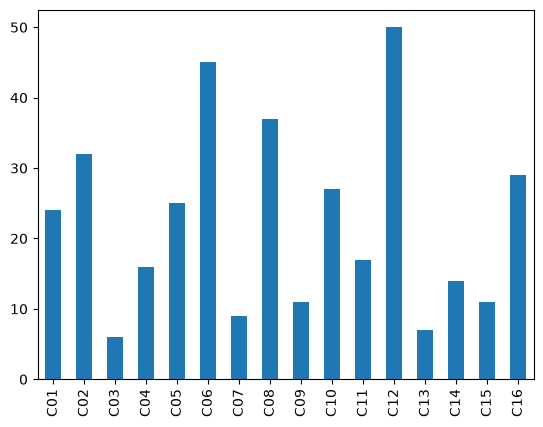

In [18]:
%matplotlib inline
df2.loc['合計'].plot(kind='bar');

## コード2.13（p. 65）

In [20]:
from pulp import * # 最適化ソルバー
from itertools import product # 繰り返しのため
import math # floor, ceil 関数のため
MEPS = 1.0e-6 
n = len(df.index) # 学生の人数
class_columns = df.select_dtypes(include='number').columns
m = len(class_columns) # クラスの数
lb = math.floor(n/m) # 1クラス人数の下限
ub = math.ceil(n/m) # 1クラス人数の上限
# 満足度 希望順位:点数 のフォーマット
score = {1:100, 2:50, 3:20, 4:0}
ngscore = -100000 # 希望外
prob = LpProblem('ClassAssignment', sense=LpMaximize)
# 変数 x と満足度関数 p を同時に設定
x = {}
p = {}
for i,j in product(df.index, class_columns):
    x[i,j] = LpVariable('x('+str(i)+','+str(j)+')', lowBound=0)
    p[i,j] = score[int(df.loc[i,j])] \
        if df.loc[i,j]>MEPS else ngscore
# 目的関数
prob += lpSum(p[i,j]*x[i,j] \
              for i,j in product(df.index, class_columns))
# 制約式
for i in df.index:
    prob += lpSum(x[i,j] for j in class_columns) == 1
for j in class_columns:
    prob += lpSum(x[i,j] for i in df.index) >= lb
    prob += lpSum(x[i,j] for i in df.index) <= ub
# 最適化
prob.solve()
# 解の出力
print(LpStatus[prob.status])
print('学生の満足度の総計は',  int(value(prob.objective)))
print('学生一人あたりの平均満足度は',  int(value(prob.objective))/90.0)

Optimal
学生の満足度の総計は 6220
学生一人あたりの平均満足度は 69.11111111111111


## コード2.14（p. 67）

In [21]:
dfr = df.loc[:, class_columns].copy()
for i,j in product(dfr.index,dfr.columns):
    dfr.loc[i,j] = df.loc[i,j] if x[i,j].varValue > MEPS else 0

d2 = {j: [(dfr.loc[:,j]==1).sum(), (dfr.loc[:,j]==2).sum(),
        (dfr.loc[:,j]==3).sum(), (dfr.loc[:,j]==4).sum(),
        (dfr.loc[:,j]>0).sum(),
          sum([p[i,j] for i in df.index
               if x[i,j].varValue > MEPS])] for j in dfr.columns}
df3 = pd.DataFrame(d2,
        index=['第1希望','第2希望','第3希望',
               '第4希望','合計', 'クラス満足度'])
df3

,C01,C02,C03,C04,C05,C06,C07,C08,C09,C10,C11,C12,C13,C14,C15,C16
第1希望,1,6,1,1,6,6,0,2,5,6,2,6,1,4,0,4
第2希望,2,0,0,3,0,0,3,4,0,0,3,0,0,1,0,2
第3希望,1,0,4,1,0,0,2,0,0,0,1,0,0,1,1,0
第4希望,1,0,0,1,0,0,0,0,0,0,0,0,4,0,4,0
合計,5,6,5,6,6,6,5,6,5,6,6,6,5,6,5,6
クラス満足度,220,600,180,270,600,600,190,400,500,600,370,600,100,470,20,500


# 2.4.2 DEA

## コード2.15（pp. 70-71）

In [22]:
import numpy as np
from pulp import *
MEPS = 1.0e-6

def DEA_CCR(x, y, DMUs):
    m, n = x.shape
    s, n = y.shape

    res = []
    for o in range(n):
        prob = LpProblem('DMU_'+str(o), LpMaximize)
        v = [LpVariable('v'+str(i), lowBound=0,
                        cat='Continuous') for i in range(m)]
        u = [LpVariable('u'+str(i), lowBound=0,
                        cat='Continuous') for i in range(s)]
        
        prob += lpDot(u, y[:,o]) # 目的関数
        
        #　制約条件
        prob += lpDot(v, x[:,o])==1, 'Normalize'+str(o) 
        for j in range(n):
            prob += lpDot(u, y[:,j]) <= lpDot(v, x[:, j])

        prob.solve()
        vs = np.array([v[i].varValue for i in range(m)]) # v*
        us = np.array([u[i].varValue for i in range(s)])  # u*
        # 参照集合作成
        (eo,) = np.where(np.abs(np.dot(vs,x)-np.dot(us,y))<=MEPS) 
        res.append([DMUs[o], value(prob.objective),
                    set(eo), tuple(vs), tuple(us)])
    return res

In [24]:
x = np.array([[321.774, 1376.049, 64.716, 143.457,
    80.689, 64.395, 126.573, 23.969, 59.798, 35.94],
  [14682.739, 5320.232, 2676.52, 999.832, 3226.726,
    2361.317, 4780.944, 975.012, 1745.045, 1359.773]])
y = np.array([[46, 26, 27, 19, 17, 10, 12, 8, 8, 4],
 [37, 18, 23, 18, 10, 18, 8, 11, 12, 3],
 [38, 26, 17, 19, 15, 14, 21, 10, 8, 15]])

DMUs = ['アメリカ', '中国', 'イギリス', 'ロシア', 'ドイツ', 'フランス',
    '日本', 'オーストラリア', 'イタリア', 'カナダ']

res = DEA_CCR(x,y, DMUs)
results = [[dmu, efficiency, [res[index][0] for index in references]]
           for dmu, efficiency, references, _, _ in res]
results = sorted(results, key=lambda result: result[1], reverse=True)

In [25]:
results

[['オーストラリア', np.float64(1.000000002), ['カナダ', 'ロシア', 'オーストラリア']],
 ['ロシア', np.float64(1.0000000009999999), ['ロシア']],
 ['カナダ', np.float64(0.9999999978), ['カナダ', 'ロシア', 'オーストラリア']],
 ['イギリス', np.float64(0.9999999970000001), ['イギリス', 'オーストラリア']],
 ['フランス', np.float64(0.666693702), ['ロシア', 'オーストラリア']],
 ['イタリア', np.float64(0.581318664), ['ロシア', 'オーストラリア']],
 ['ドイツ', np.float64(0.567588247), ['イギリス', 'ロシア', 'オーストラリア']],
 ['日本', np.float64(0.4118923692), ['カナダ', 'ロシア', 'オーストラリア']],
 ['アメリカ', np.float64(0.3697814572), ['イギリス', 'オーストラリア']],
 ['中国', np.float64(0.257167573), ['ロシア']]]

# 2.4.3 多面体描画

## コード2.16（pp. 72-73）

In [1]:
import numpy as np
from itertools import combinations
MEPS = 1.0e-6
# 多面体を定義する不等式の作成
np.random.seed(2)
n, d = 40, 3
A = np.random.randint(0,100,(n,d))
b = np.sqrt(np.dot(A**2,np.ones(d))).astype(np.int64)
m, n = np.shape(A)
# 不等式 b + A x >= 0 の形式に合わせる．
eb = np.hstack((b, np.zeros(n)))
eA = np.vstack((-A,np.identity(n)))
# 3つの境界平面の交点から実行可能な頂点を列挙する．
vertices = []
for indices in combinations(range(m + n), d):
    boundary = eA[list(indices)]
    if np.linalg.matrix_rank(boundary) < d:
        continue
    vertex = np.linalg.solve(boundary, -eb[list(indices)])
    if np.all(eb + np.dot(eA, vertex) >= -MEPS):
        if not any(np.allclose(vertex, existing, atol=MEPS) for existing in vertices):
            vertices.append(vertex)

vlist = np.array(vertices, dtype=np.float64)
# 付加情報の計算
zerosets = [set(i for i in range(m+n)
                if abs(eb[i] + np.dot(eA[i], vertex)) <= MEPS)
            for vertex in vlist]
elist = [[i,j] for i,j in combinations(range(len(vlist)),2)
         if len(zerosets[i].intersection(zerosets[j])) >= 2]

## コード2.17（p. 73）

In [2]:
from vpython import *
# vpython 初期設定
scene = canvas(width = 800,height = 600)
vmin = np.min(vlist)-0.5
length = np.max(vlist)-vmin+0.5
scene.up = vector(0,0,1)
scene.forward = vector(-1,-1,-1)
scene.center = vector(0,0,0)
scene.range = 0.9*length
scene.background = color.white
cb = color.black
# x,y,z軸を描画
arrow(pos=vector(vmin,0,0),axis=vector(length,0,0),
      shaftwidth=0.002,headwidth=0.05,color=cb)
arrow(pos=vector(0,vmin,0),axis=vector(0,length,0),
      shaftwidth=0.002,headwidth=0.05,color=cb)
arrow(pos=vector(0,0,vmin),axis=vector(0,0,length),
      shaftwidth=0.002,headwidth=0.05,color=cb)
# 頂点と稜線を描画
vertices = [sphere(pos=vector(*v),
                radius=0.01,color=cb) for v in vlist]
edges = [curve(pos=[vector(*vlist[i]), vector(*vlist[j])],
               radius=0.007,color=cb) for [i,j] in elist]

ModuleNotFoundError: No module named 'pkg_resources'